# Nanoparticle (core/shell) scattering VAE
A simple tool for generating X-ray small-angle scattering (SAXS) curves from MD-like variations relevant parameters of nanoparticles embedded in polymers with various scattering length densities (SLDs). This short side projects answers the simple question: "What nanoparticle + polymer composite would give this scattering pattern?", answered using a variational autoencoder (VAE) neural network.

First, the scattering patterns of spherical core/shell NPs are simulated using analytical form factor formulas (a structure factor is optional).
Second, a VAE is trained on the simulated input data. The latent space encoding is plotted together with the decoded output data which is then compared to the simulated input data.
Third, a target pattern is sampled and the nearest generated configuration according to the trained VAE is determined.

# Step 1: simulate SAXS patterns
Nanoparticles (core/shell morphology) in a polymer matrix are generated and their scattering pattern is calculated using a simple form factor parameter variation.

In [64]:
import numpy as np
import matplotlib.pyplot as plt

#Simulation parameters
q = np.logspace(-2, 0, 200) # units of 0.01-1 inverse Angström

#Functions used for the scattering pattern generation
def sphere_ff(q, R):
  #Sphere form factor amplitude
  x = q * R
  with np.errstate(divide = 'ignore', invalid = 'ignore'):
    return np.where(x == 0, 1.0, 3 * (np.sin(x) - x * np.cos(x)) / x**3) #normalized to P(0) = 1

def core_shell_intensity(q, R_core, d_shell, sld_core = 1.0, sld_shell = 0.5, sld_solvent = 0.0, scale = 1.0, bkg = 0.05):
  #Core/shell polymer-coated NP + non-interacting state (S(q) = 1)
  R_total = R_core + d_shell
  V_core = 4/3 * np.pi * R_core**3
  V_total = 4/3 * np.pi * R_total**3

  contrast_core = sld_core - sld_shell #SLD contrast of the core
  contrast_shell = sld_shell - sld_solvent #SLD contrast of the shell

  # Form factor amplitude
  F = (contrast_core * V_core * sphere_ff(q, R_core) + contrast_shell * V_total * sphere_ff(q, R_total))

  #Form factor which is F^2/V_total
  Pq = np.abs(F)**2 / V_total**2 #normalized P(0) = 1
  Iq = scale * Pq + bkg # no structure factor
  # Iq = scale * Pq * 1 / (1 + 8 * scale /10 )
  return Iq

# Generate parameter variations
np.random.seed(42)
N = 5000 # number of generated patterns
R_core = np.random.uniform(20, 60, N) # random nanoparticle sizes
d_shell = np.random.uniform(1, 12, N) # polymer coating thicknesses
scale = np.random.uniform(0.01, 0.5, N) # random volume fractions
sld_shell = np.random.uniform(0.2, 0.8, N) # polymer density/composition variation

X = np.zeros((N, len(q))) # scattering curves are saved in X
params = np.stack([R_core, d_shell, scale, sld_shell], axis = 1) #One scattering curve corresponds to one set of params

for i in range(N):
  Iq = core_shell_intensity(q, R_core[i], d_shell[i], scale = scale[i], sld_shell = sld_shell[i])
  # Adding an artificial noise + polymer incoherent scattering background
  Iq += 0.001 * np.random.randn(len(q)) * Iq
  # Simple polymer matrix contribution, Debye-like
  Rg_poly = 5.0
  x = q**2 * Rg_poly**2
  Iq += 0.001 * (2 * (np.exp(-x) + x - 1) / x**2)
  X[i] = Iq

# Normalize for the subsequent VAE training step
X = np.log10(X + 1e-6)
X = (X - X.min(axis = 1, keepdims = True)) / (X.max(axis = 1, keepdims = True) - X.min(axis = 1, keepdims = True) + 1e-8 )

np.save("saxs_dataset.npy", X)
np.save("params.npy", params) # keep labels for inverse design
print("Dataset generated (number of scattering patterns, I vs. q datapoints per scattering pattern):\n", X.shape)

Dataset generated (number of scattering patterns, I vs. q datapoints per scattering pattern):
 (5000, 200)


# Step 2: train 1D VAE

A simple PyTorch MLP VAE is trained on the previosuly generated scattering patterns with 200 input datapoints (200-dimensional normalized curves).

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class VAE(nn.Module):
    def __init__(self, input_dim=200, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU())
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU(), nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, input_dim))

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Data loader
dataset = TensorDataset(torch.tensor(X, dtype=torch.float32))
loader = DataLoader(dataset, batch_size=64, shuffle=True)

model = VAE(latent_dim=8) #Create a VAE with latent dimensions of 8
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.0001 * kl   # beta = 0.0001 for stability

for epoch in range(101):
    for batch in loader:
        x = batch[0]
        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    if epoch % 10 == 0: print(f"Epoch {epoch} loss: {loss.item():.4f}")

Epoch 0 loss: 0.0120
Epoch 10 loss: 0.0025
Epoch 20 loss: 0.0037
Epoch 30 loss: 0.0084
Epoch 40 loss: 0.0056
Epoch 50 loss: 0.0033
Epoch 60 loss: 0.0039
Epoch 70 loss: 0.0052
Epoch 80 loss: 0.0035
Epoch 90 loss: 0.0011
Epoch 100 loss: 0.0035


Plot the simulated data vs. the AI model-trained reconstructed data + latent space (color distinguishing by R_Core). Exemplary latent space plots are shown.

Model and data saved (vae_model.pth + saxs_dataset.npy + params.npy)


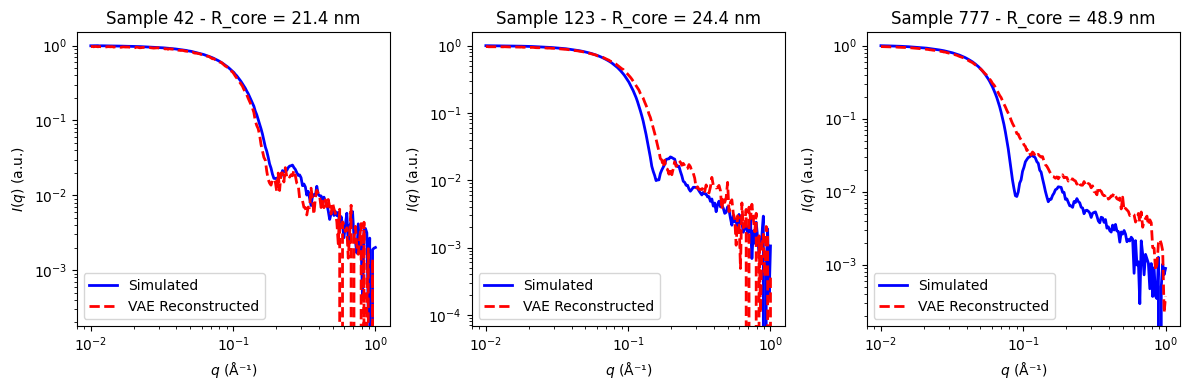

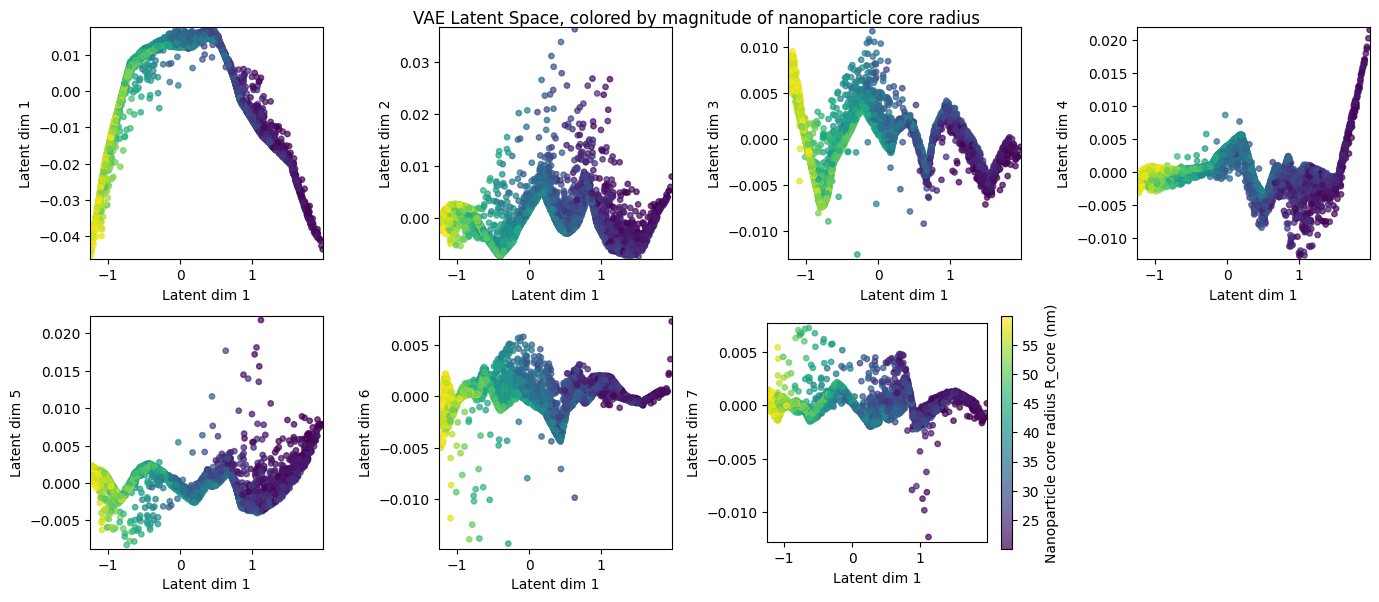

Plots saved: real_vs_reconstructed.png + latent_space.png


In [66]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Save model and data
torch.save(model.state_dict(), 'vae_model.pth') #recommended approach which is the smallest model
# torch.save(model, 'vae_full_model.pth') # alternative (full model)

#save dataset + parameters for reproducibility and subsequent inverse design
np.save('saxs_dataset.npy', X)
np.save('params.npy', params) # R_core, thickness, etc.

print("Model and data saved (vae_model.pth + saxs_dataset.npy + params.npy)")

# plot real vs. reconstructed patterns
model.eval()
with torch.no_grad():
    test_idx = [42, 123, 777] # These are just example indices of the generated datasets from before
    x_test = torch.tensor(X[test_idx], dtype=torch.float32)
    recon, _, _ = model(x_test)
    recon = recon.numpy()

plt.figure(figsize=(12, 4))
for i, idx in enumerate(test_idx):
    plt.subplot(1, 3, i+1)
    plt.plot(q, X[idx], 'b-', label='Simulated', linewidth=2)
    plt.plot(q, recon[i], 'r--', label='VAE Reconstructed', linewidth=2)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('$q$ (Å⁻¹)')
    plt.ylabel('$I$($q$) (a.u.)')
    plt.title(f'Sample {idx} - R_core = {params[idx,0]:.1f} nm')
    plt.legend()
plt.tight_layout()
plt.savefig('real_vs_reconstructed.png', dpi=300, bbox_inches='tight')
plt.show()

# plot latent Space (colored by magnitude of R_core)
with torch.no_grad():
    full_data = torch.tensor(X, dtype=torch.float32)
    mu, _ = model.encode(full_data) #use mean of the latent distribution
    latent = mu.numpy()

# Reduce to 2D for visualization
pca = PCA(n_components=8)
latent_2d = pca.fit_transform(latent)

fig, ax = plt.subplots(2, 4, figsize=(14,6), subplot_kw=dict(box_aspect=1))
fig.delaxes(ax[1,3])
for i in range(7):
  plt.subplot(2, 4, i+1)
  scatter = plt.scatter(latent_2d[:,0], latent_2d[:,i+1],
                       c=params[:,0], cmap='viridis', s=15, alpha=0.7)
  plt.xlabel(f'Latent dim {1}')
  plt.ylabel(f'Latent dim {i+1}')
  pad = 5e-4
  plt.xlim(latent_2d[:,0].min() - pad, latent_2d[:,0].max() + pad)
  plt.ylim(latent_2d[:,i+1].min() - pad, latent_2d[:,i+1].max() + pad)
plt.suptitle('VAE Latent Space, colored by magnitude of nanoparticle core radius')
fig.colorbar(scatter, label='Nanoparticle core radius R_core (nm)')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
plt.savefig('latent_space.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plots saved: real_vs_reconstructed.png + latent_space.png")

# Step 3: Scattering inverse design

Answering the question what composite a given pattern corresponds to.
A sample $z$ is created which is assumed to be a normal distribution ($N(0, 1)$). This is the prior distribution the VAE was trained on.

First, take a target simulated scattering curve.
Second, start with a random guess in latent space:

> z = torch.nn.Parameter(torch.randn(1, 8))

 The previously pre-trained decoder then maps this normal-distributed $z$ to a new physically plausible scattering curve via gradient descent (Adam) for 800 steps:

 > recon = model.decode(z)
 >
 > loss = nn.MSELoss()(recon, target)
 >
 > loss.backward()
 >
 > opt.step()

After these 800 steps, z has been optimized so that the decoder(z) reproduces the target pattern.
In principle, hundreds of novel scattering patterns can be generated from the pretrained VAE this way.

Third, The final optimized z is converted back into real physical parameters using the small regressor trained earlier:

> pred_params = reg.predict(z.detach().numpy())[0]

This will return the 4 predicted physical parameters and answers "What composite generated this pattern?".
The final reconstructed curve is displayed alongside the nearest training match is and the input scattering pattern are shown.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Predicted composite: R_core = 16.1 nm, polymer coating = 2.3 nm, density proxy = 0.42


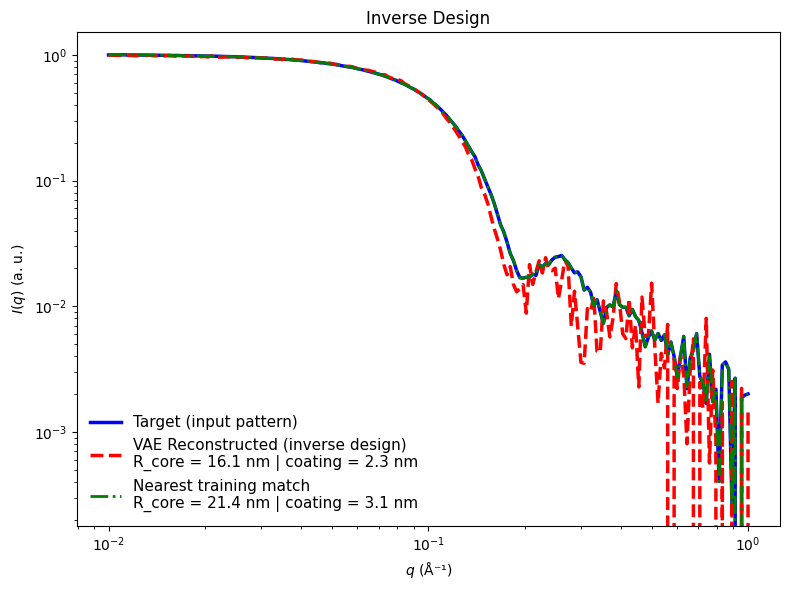

✅ Plot saved as 'inverse_design_final_plot.png'
Nearest training sample index: 42 (for reference)


In [72]:
# Option A – fast: train tiny regressor (convert latent space to physical parameters)
from sklearn.neural_network import MLPRegressor
latent_train = model.encode(torch.tensor(X, dtype=torch.float32))[0].detach().numpy()
reg = MLPRegressor(hidden_layer_sizes=(16,8), max_iter=500).fit(latent_train, params)

# Option B – differentiable optimization in latent space (more powerful)
def inverse_design(target_iq, steps=800, lr=0.05):
    target = torch.tensor(target_iq, dtype=torch.float32).unsqueeze(0)
    z = torch.nn.Parameter(torch.randn(1, 8))
    opt = optim.Adam([z], lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        recon = model.decode(z)
        loss = nn.MSELoss()(recon, target)
        loss.backward()
        opt.step()

    # Predict the 4 physical parameters from latent z
    pred_params = reg.predict(z.detach().numpy())[0]   # shape (4,)

    # Return the 4 parameters + reconstructed curve
    return (pred_params[0], pred_params[1], pred_params[2], pred_params[3],
            model.decode(z).detach().numpy()[0])

# Example usage
target = X[42]   # or your real experimental curve
pred_R, pred_thickness, pred_scale, pred_sld, recon = inverse_design(target)
print(f"Predicted composite: R_core = {pred_R:.1f} nm, polymer coating = {pred_thickness:.1f} nm, density proxy = {pred_scale:.2f}")

# Find nearest training match (Euclidean distance in normalized curve space)
distances = np.linalg.norm(X - target.reshape(1, -1), axis=1)
nearest_idx = np.argmin(distances)
nearest_curve = X[nearest_idx]
nearest_params = params[nearest_idx]

# Plot target vs. reconstructed vs nearest training match ===
plt.figure(figsize=(8, 6))
plt.plot(q, target, 'b-', label='Target (input pattern)', linewidth=2.5)
plt.plot(q, recon, 'r--', label=f'VAE Reconstructed (inverse design)\n'
                                f'R_core = {pred_R:.1f} nm | coating = {pred_thickness:.1f} nm',
         linewidth=2.5)
plt.plot(q, nearest_curve, 'g-.', label=f'Nearest training match\n'
                                        f'R_core = {nearest_params[0]:.1f} nm | coating = {nearest_params[1]:.1f} nm',
         linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$q$ (Å⁻¹)')
plt.ylabel('$I$($q$) (a. u.)')
plt.title('Inverse Design')
plt.legend(fontsize=11, frameon=False)
plt.tight_layout()

plt.savefig('inverse_design_final_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved as 'inverse_design_final_plot.png'")
print(f"Nearest training sample index: {nearest_idx} (for reference)")